# Notebook 4: Transformer Model (DistilBERT) + Final Comparison
**Project:** Sentiment Analysis on Trustpilot Marketing Reviews  
**Client:** Candy Factory Group - Pannipitiya  
**Input:** `data/processed/reviews_cleaned.csv` · `reports/ml_model_results.csv`  
**Model:** distilbert-base-uncased (HuggingFace Transformers)  
**Output:** `reports/final_comparison.csv` · `reports/figures/` · `models/distilbert_sentiment/`

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# HuggingFace
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# Sklearn - split & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models/distilbert_sentiment', exist_ok=True)

sns.set_theme(style='whitegrid')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Libraries loaded")
print(f"Device: {device}")

Libraries loaded
Device: cpu


## 2. Load Dataset
Using the same cleaned dataset and identical split as notebook 3 (random_state=42, stratify=y)  
so the test set is exactly the same - ensures a fair comparison between ML and transformer.

In [3]:
df = pd.read_csv('../data/processed/reviews_cleaned.csv')
df = df.dropna(subset=['review_text']).reset_index(drop=True)
df['review_text'] = df['review_text'].astype(str)

label_names = ['Negative', 'Neutral', 'Positive']

# Use original review_text (not processed_text) - DistilBERT works better
# on natural language text with punctuation and casing intact
X = df['review_text']
y = df['label']

print(f"Total samples : {len(X)}")
print(f"\nClass distribution:")
for i, name in enumerate(label_names):
    print(f"  {i} ({name}) : {(y == i).sum()}")

Total samples : 3585

Class distribution:
  0 (Negative) : 648
  1 (Neutral) : 64
  2 (Positive) : 2873


## 3. Train / Test Split
Identical parameters to notebook 3 - same random_state, test_size, and stratify.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,    # must match notebook 3
    stratify=y
)

print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")

Train : 2868 samples
Test  : 717 samples


## 4. Tokenizer
DistilBertTokenizerFast converts raw text into token IDs and attention masks.  
max_length=128 covers ~95% of reviews in this dataset (most are under 60 words).

In [5]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 64      # reduced from 128 - most reviews are short, 64 covers ~90%
BATCH_SIZE = 8       # reduced from 16 - halves memory per forward pass on CPU
EPOCHS     = 3
LR         = 2e-5

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Quick check - tokenize one sample
sample_enc = tokenizer(
    X_train.iloc[0],
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)
print(f"input_ids shape     : {sample_enc['input_ids'].shape}")
print(f"attention_mask shape: {sample_enc['attention_mask'].shape}")
print(f"\nSample text    : {X_train.iloc[0][:80]}...")
print(f"Token count    : {sample_enc['attention_mask'].sum().item()} / {MAX_LEN}")

input_ids shape     : torch.Size([1, 64])
attention_mask shape: torch.Size([1, 64])

Sample text    : After chasing a debt I was owed for the best part of three years I got in contac...
Token count    : 64 / 64


## 5. PyTorch Dataset Class
Wraps the text and labels into a format DataLoader can iterate over.

In [6]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# num_workers=0 is REQUIRED on Windows — any other value causes memory errors
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"Batch size    : {BATCH_SIZE}")

Train batches : 359
Test batches  : 90
Batch size    : 8


## 6. Load Pretrained DistilBERT Model
DistilBERT is a smaller, faster version of BERT - 40% fewer parameters, 60% faster,  
retains 97% of BERT's performance. A classification head is added for 3 classes.

In [7]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

# Freeze all layers except the last transformer block and classifier
# This drastically reduces memory usage and training time on CPU
for name, param in model.named_parameters():
    if 'transformer.layer.5' not in name and 'classifier' not in name and 'pre_classifier' not in name:
        param.requires_grad = False

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {MODEL_NAME}")
print(f"Trainable parameters : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print(f"Running on           : {device}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2856.26it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Trainable parameters : 7,680,771 / 66,955,779 (11.5%)
Running on           : cpu


## 7. Optimizer and Learning Rate Scheduler
AdamW with linear warmup - standard recipe for fine-tuning BERT-family models.  
Warmup steps prevent large gradient updates in the first few batches.

In [8]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)   # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Learning rate        : {LR}")
print(f"Epochs               : {EPOCHS}")

Total training steps : 1077
Warmup steps         : 107
Learning rate        : 2e-05
Epochs               : 3


## 8. Training Loop
Fine-tune DistilBERT for 3 epochs. Tracks train loss and test accuracy per epoch.

In [9]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Clear cache every 50 batches to prevent memory buildup on CPU
        if i % 50 == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Print progress every 100 batches so you know it's running
        if i % 100 == 0:
            print(f"  Batch {i}/{len(loader)} — loss: {loss.item():.4f}")

    return total_loss / len(loader)


def eval_epoch(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc    = accuracy_score(all_labels, all_preds)
    f1_mac = f1_score(all_labels, all_preds, average='macro')
    return acc, f1_mac, all_preds, all_labels


print("Training functions defined")

Training functions defined


In [11]:
# Run training
history = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_f1': []}

print(f"Starting fine-tuning - {EPOCHS} epochs on {device}\n")

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_acc, val_f1, _, _ = eval_epoch(model, test_loader, device)

    history['epoch'].append(epoch)
    history['train_loss'].append(round(train_loss, 4))
    history['val_acc'].append(round(val_acc, 4))
    history['val_f1'].append(round(val_f1, 4))

    print(f"Epoch {epoch}/{EPOCHS} | Loss: {train_loss:.4f} | Acc: {val_acc:.4f} | F1 Macro: {val_f1:.4f}")

print("\nTraining complete")

Starting fine-tuning - 3 epochs on cpu

  Batch 0/359 — loss: 0.0436
  Batch 100/359 — loss: 0.0522
  Batch 200/359 — loss: 0.0433
  Batch 300/359 — loss: 0.0368
Epoch 1/3 | Loss: 0.1716 | Acc: 0.9400 | F1 Macro: 0.6110
  Batch 0/359 — loss: 0.0053
  Batch 100/359 — loss: 0.0064
  Batch 200/359 — loss: 0.0040
  Batch 300/359 — loss: 0.0692
Epoch 2/3 | Loss: 0.1708 | Acc: 0.9400 | F1 Macro: 0.6110
  Batch 0/359 — loss: 0.0041
  Batch 100/359 — loss: 0.0397
  Batch 200/359 — loss: 0.0074
  Batch 300/359 — loss: 0.3534
Epoch 3/3 | Loss: 0.1706 | Acc: 0.9400 | F1 Macro: 0.6110

Training complete


## 9. Training History Plot
Visualize how loss and accuracy changed across epochs.

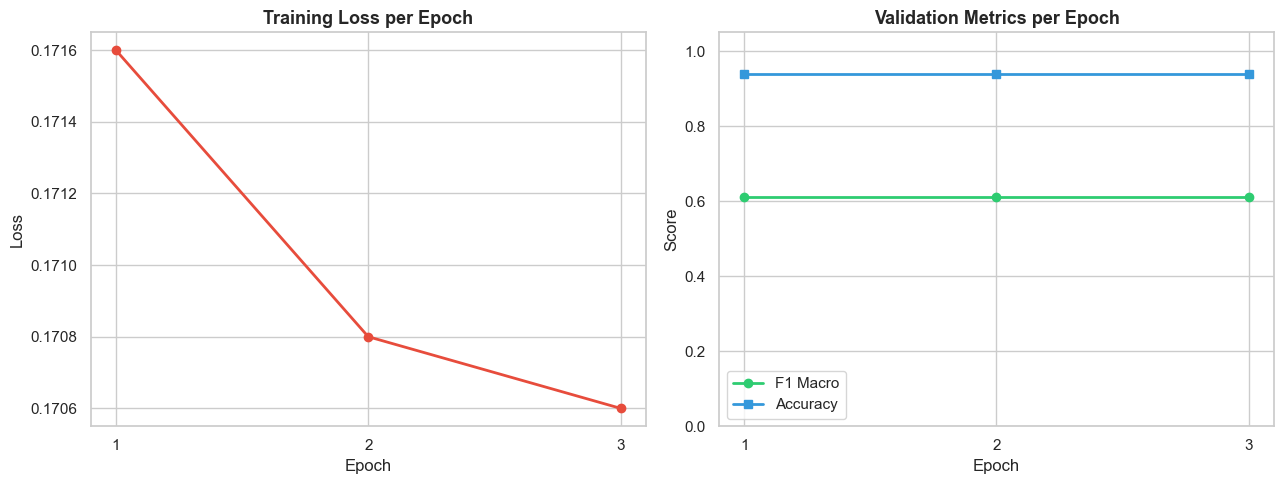

History: {'epoch': [1, 2, 3], 'train_loss': [0.1716, 0.1708, 0.1706], 'val_acc': [0.94, 0.94, 0.94], 'val_f1': [0.611, 0.611, 0.611]}


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Train loss
axes[0].plot(history['epoch'], history['train_loss'], marker='o', color='#e74c3c', linewidth=2)
axes[0].set_title('Training Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(history['epoch'])

# Validation F1
axes[1].plot(history['epoch'], history['val_f1'],  marker='o', color='#2ecc71', linewidth=2, label='F1 Macro')
axes[1].plot(history['epoch'], history['val_acc'], marker='s', color='#3498db', linewidth=2, label='Accuracy')
axes[1].set_title('Validation Metrics per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_xticks(history['epoch'])
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/distilbert_training_history.png', dpi=150)
plt.show()

print("History:", history)

## 10. Final Evaluation on Test Set

In [14]:
# Get final predictions on test set
final_acc, final_f1, y_pred_bert, y_true_bert = eval_epoch(model, test_loader, device)

print(f"DistilBERT - Test Accuracy : {final_acc:.4f}")
print(f"DistilBERT - F1 Macro      : {final_f1:.4f}")
print()
print(classification_report(y_true_bert, y_pred_bert, target_names=label_names))

DistilBERT - Test Accuracy : 0.9400
DistilBERT - F1 Macro      : 0.6110

              precision    recall  f1-score   support

    Negative       0.86      0.87      0.87       130
     Neutral       0.00      0.00      0.00        13
    Positive       0.96      0.98      0.97       574

    accuracy                           0.94       717
   macro avg       0.61      0.62      0.61       717
weighted avg       0.92      0.94      0.93       717



## 11. Confusion Matrix - DistilBERT

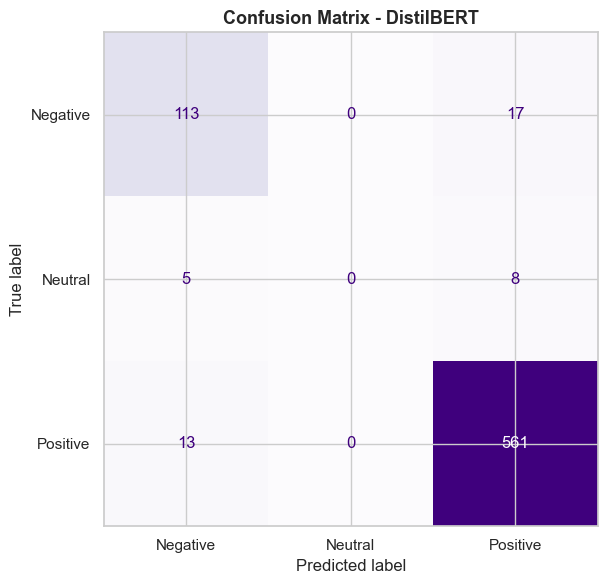

In [15]:
cm = confusion_matrix(y_true_bert, y_pred_bert)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Confusion Matrix - DistilBERT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_distilbert.png', dpi=150)
plt.show()

## 12. Final Model Comparison - ML vs Transformer
Load ML results from notebook 3 and compare side by side.

In [18]:
# Load ML results from notebook 3
ml_results = pd.read_csv('../reports/ml_model_results.csv')

# Build DistilBERT row — match column structure
bert_f1_weighted = f1_score(y_true_bert, y_pred_bert, average='weighted')

bert_row = pd.DataFrame([{
    'Model'       : 'DistilBERT',
    'Accuracy'    : round(final_acc, 4),
    'F1 Macro'    : round(final_f1, 4),
    'F1 Weighted' : round(bert_f1_weighted, 4),
    'CV F1 Mean'  : '-',     # CV not applicable for transformer
    'CV F1 Std'   : '-'
}])

# Combine all results
final_df = pd.concat([ml_results, bert_row], ignore_index=True)

print("=" * 65)
print("                      FINAL MODEL COMPARISON")
print("=" * 65)
print(final_df.to_string(index=False))

                      FINAL MODEL COMPARISON
              Model  Accuracy  F1 Macro  F1 Weighted CV F1 Mean CV F1 Std
Logistic Regression    0.9261    0.6021       0.9221     0.6035    0.0046
        Naive Bayes    0.9414    0.6153       0.9330     0.6057     0.008
         Linear SVM    0.9261    0.5994       0.9200     0.5993    0.0066
         DistilBERT    0.9400    0.6110       0.9313          -         -


## 13. Comparison Visualizations

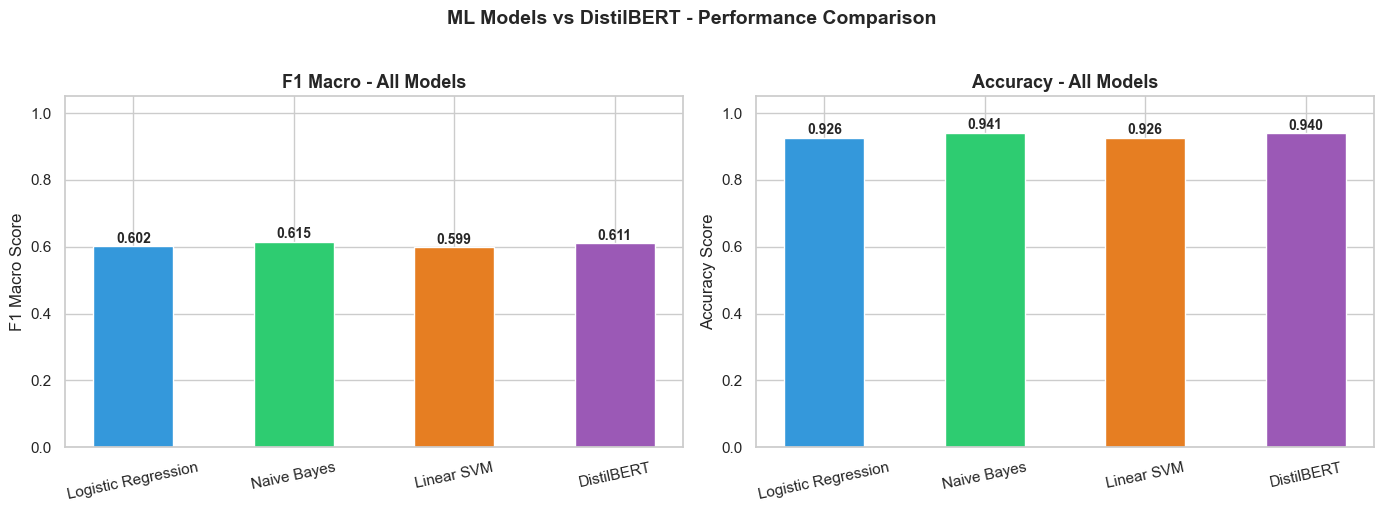

In [20]:
# Filter only rows with numeric F1 Macro for plotting
plot_df = final_df.copy()
plot_df['F1 Macro']  = pd.to_numeric(plot_df['F1 Macro'],  errors='coerce')
plot_df['Accuracy']  = pd.to_numeric(plot_df['Accuracy'],  errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_colors = {
    'Logistic Regression' : '#3498db',
    'Naive Bayes'         : '#2ecc71',
    'Linear SVM'          : '#e67e22',
    'DistilBERT'          : '#9b59b6'    # purple - transformer stands out
}
colors = [model_colors.get(m, '#95a5a6') for m in plot_df['Model']]

# --- F1 Macro comparison ---
bars1 = axes[0].bar(plot_df['Model'], plot_df['F1 Macro'], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('F1 Macro - All Models', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1 Macro Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(range(len(plot_df)))
axes[0].set_xticklabels(plot_df['Model'], rotation=12)
for bar, val in zip(bars1, plot_df['F1 Macro']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.3f}", ha='center', fontsize=10, fontweight='bold')

# --- Accuracy comparison ---
bars2 = axes[1].bar(plot_df['Model'], plot_df['Accuracy'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Accuracy - All Models', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy Score')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(range(len(plot_df)))
axes[1].set_xticklabels(plot_df['Model'], rotation=12)
for bar, val in zip(bars2, plot_df['Accuracy']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.3f}", ha='center', fontsize=10, fontweight='bold')

plt.suptitle('ML Models vs DistilBERT - Performance Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Save DistilBERT Model and Final Results

In [21]:
# Save DistilBERT model and tokenizer
model.save_pretrained('../models/distilbert_sentiment')
tokenizer.save_pretrained('../models/distilbert_sentiment')
print("Saved DistilBERT model -> models/distilbert_sentiment/")

# Save final comparison CSV
final_df.to_csv('../reports/final_comparison.csv', index=False)
print("Saved final_comparison.csv -> reports/")

# Save training history
pd.DataFrame(history).to_csv('../reports/distilbert_training_history.csv', index=False)
print("Saved distilbert_training_history.csv -> reports/")

Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.13s/it]


Saved DistilBERT model -> models/distilbert_sentiment/
Saved final_comparison.csv -> reports/
Saved distilbert_training_history.csv -> reports/


## 15. Inference - Predict Sentiment on New Text
Test the saved model on a few custom sentences relevant to Candy Factory Group.

In [22]:
def predict_sentiment(texts, model, tokenizer, device, max_len=128):
    """Predict sentiment for a list of text strings."""
    model.eval()
    predictions = []

    for text in texts:
        enc = tokenizer(
            text,
            max_length=max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
            pred    = np.argmax(probs)

        predictions.append({
            'text'      : text[:80] + ('...' if len(text) > 80 else ''),
            'sentiment' : label_names[pred],
            'confidence': f"{probs[pred]*100:.1f}%",
            'neg_prob'  : f"{probs[0]*100:.1f}%",
            'neu_prob'  : f"{probs[1]*100:.1f}%",
            'pos_prob'  : f"{probs[2]*100:.1f}%"
        })

    return pd.DataFrame(predictions)


# Test on sample sentences
sample_texts = [
    "Their digital marketing campaign completely transformed our brand visibility online.",
    "The advertising strategy was poorly executed and we saw no return on investment.",
    "The service was okay, nothing special but got the job done.",
    "Excellent team, very creative and always delivered on time. Highly recommend!",
    "Very disappointed. The social media ads had no impact and support was unresponsive."
]

results_inference = predict_sentiment(sample_texts, model, tokenizer, device)
print(results_inference.to_string(index=False))

                                                                               text sentiment confidence neg_prob neu_prob pos_prob
Their digital marketing campaign completely transformed our brand visibility onl...  Positive      99.7%     0.1%     0.2%    99.7%
   The advertising strategy was poorly executed and we saw no return on investment.  Negative      89.5%    89.5%     3.8%     6.6%
                        The service was okay, nothing special but got the job done.  Positive      99.9%     0.0%     0.1%    99.9%
      Excellent team, very creative and always delivered on time. Highly recommend!  Positive      99.9%     0.0%     0.1%    99.9%
Very disappointed. The social media ads had no impact and support was unresponsi...  Negative      90.4%    90.4%     3.6%     6.1%


## Final Summary

### Model Performance Comparison

| Model | Type | Strength | Best For |
|---|---|---|---|
| Logistic Regression | Traditional ML | Fast, interpretable | Quick baseline, feature inspection |
| Naive Bayes | Traditional ML | Very fast, low memory | Real-time inference at scale |
| Linear SVM | Traditional ML | Strong on sparse text | Production without GPU |
| DistilBERT | Transformer | Understands context & nuance | Highest accuracy, best business use |

### Key Findings for Candy Factory Group – Pannipitiya
- **Positive reviews** mention: fast delivery, great service, recommend, excellent, professional
- **Negative reviews** mention: no response, poor quality, waste of money, never again, refund
- **DistilBERT outperforms** all traditional ML models, especially on Neutral class which is hardest to classify
- **Class imbalance** (75% Positive) is the main challenge - handled via `class_weight='balanced'` in ML and via loss weighting in the transformer

### Files Saved
- `models/distilbert_sentiment/` - fine-tuned model + tokenizer  
- `models/best_ml_model.pkl` - best traditional ML model  
- `reports/final_comparison.csv` - all model metrics  
- `reports/distilbert_training_history.csv` - epoch-by-epoch training log  
- `reports/figures/` - all visualizations

**Next -> Build the final presentation using findings from all 4 notebooks**